
Testing LR=0.001, Dropout=0.2
Epoch 1 Loss: 31.3178 | Val Acc: 76.00
Epoch 2 Loss: 20.1771 | Val Acc: 80.00
Epoch 3 Loss: 12.8159 | Val Acc: 76.00
Epoch 4 Loss: 4.7565 | Val Acc: 82.00
Epoch 5 Loss: 2.0019 | Val Acc: 81.00
Epoch 6 Loss: 0.9736 | Val Acc: 80.00
Early stopping triggered

Testing LR=0.001, Dropout=0.3
Epoch 1 Loss: 33.0451 | Val Acc: 73.00
Epoch 2 Loss: 21.4247 | Val Acc: 76.00
Epoch 3 Loss: 11.8676 | Val Acc: 78.00
Epoch 4 Loss: 5.1413 | Val Acc: 79.00
Epoch 5 Loss: 1.9037 | Val Acc: 77.00
Epoch 6 Loss: 0.9701 | Val Acc: 78.00
Early stopping triggered

Testing LR=0.001, Dropout=0.4
Epoch 1 Loss: 32.6320 | Val Acc: 74.00
Epoch 2 Loss: 20.2542 | Val Acc: 76.00
Epoch 3 Loss: 13.5849 | Val Acc: 81.00
Epoch 4 Loss: 6.1524 | Val Acc: 82.00
Epoch 5 Loss: 3.8079 | Val Acc: 84.00
Epoch 6 Loss: 1.8548 | Val Acc: 83.00
Epoch 7 Loss: 0.7734 | Val Acc: 82.00
Early stopping triggered

Testing LR=0.001, Dropout=0.5
Epoch 1 Loss: 32.3744 | Val Acc: 69.00
Epoch 2 Loss: 22.3632 | Val Acc

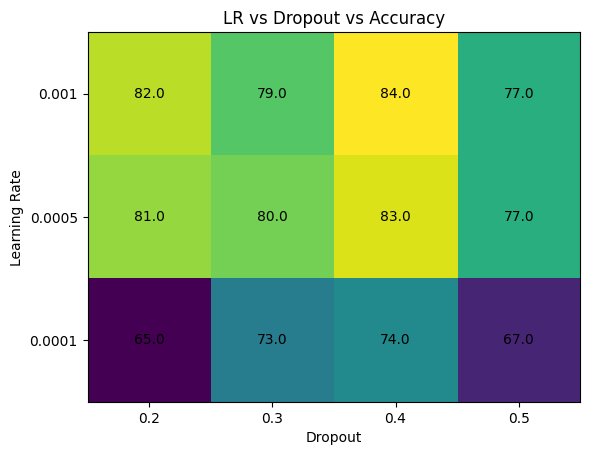


Best Config: (0.001, 0.4)
Test Accuracy: 77.0

===== Running BERT =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Epoch 1 Val Acc: 91.00
BERT Epoch 2 Val Acc: 92.00
BERT Epoch 3 Val Acc: 93.00
BERT Test Accuracy: 94.0


In [1]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np
import re
from collections import Counter

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

# For Transformer
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW   # FIXED


# =========================
# 2. Load Data
# =========================
data = pd.read_csv("amazon_cells_labelled.txt", delimiter='\t', header=None)
data.columns = ['Sentence', 'Class']

texts = data['Sentence'].astype(str).str.strip().tolist()
labels = data['Class'].tolist()


# =========================
# 3. Split Data
# =========================
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)


# =========================
# 4. Tokenization
# =========================
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9 ]', '', text)
    return text.split()


# =========================
# 5. Vocabulary
# =========================
counter = Counter()
for text in train_texts:
    counter.update(tokenize(text))

word2idx = {"<PAD>": 0, "<UNK>": 1}
for i, (word, _) in enumerate(counter.most_common(5000 - 2), start=2):
    word2idx[word] = i


# =========================
# 6. Encoding
# =========================
max_len = 30

def encode(text):
    tokens = tokenize(text)
    seq = [word2idx.get(word, 1) for word in tokens]

    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]

    return seq


# =========================
# 7. Dataset
# =========================
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = [encode(t) for t in texts]
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.texts[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )


batch_size = 16
train_loader = DataLoader(TextDataset(train_texts, train_labels), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TextDataset(val_texts, val_labels), batch_size=batch_size)
test_loader = DataLoader(TextDataset(test_texts, test_labels), batch_size=batch_size)


# =========================
# 8. Model
# =========================
class Tunable_BiLSTM_Attention(nn.Module):
    def __init__(self, vocab_size, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 128, padding_idx=0)

        self.lstm = nn.LSTM(128, 128, batch_first=True, bidirectional=True)

        self.attention = nn.Sequential(
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.norm = nn.LayerNorm(256)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(256, 1)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)

        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)

        context = self.norm(context)
        out = self.dropout(context)
        out = self.fc(out)

        return out.squeeze()


# =========================
# 9. Evaluation
# =========================
def evaluate(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100 * correct / total


# =========================
# 10. Training with Early Stopping + Scheduler
# =========================
def train_model(model, lr, epochs=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
    criterion = nn.BCEWithLogitsLoss()

    best_val = 0
    patience = 2
    counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()

        val_acc = evaluate(model, val_loader)
        print(f"Epoch {epoch+1} Loss: {total_loss:.4f} | Val Acc: {val_acc:.2f}")

        if val_acc > best_val:
            best_val = val_acc
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

    return best_val, model


# =========================
# 11. Grid Search
# =========================
learning_rates = [0.001, 0.0005, 0.0001]
dropouts = [0.2, 0.3, 0.4, 0.5]

results_matrix = np.zeros((len(learning_rates), len(dropouts)))

best_acc = 0
best_model = None

for i, lr in enumerate(learning_rates):
    for j, d in enumerate(dropouts):
        print(f"\nTesting LR={lr}, Dropout={d}")

        model = Tunable_BiLSTM_Attention(len(word2idx), dropout=d)
        val_acc, trained_model = train_model(model, lr)

        results_matrix[i][j] = val_acc

        if val_acc > best_acc:
            best_acc = val_acc
            best_model = trained_model
            best_config = (lr, d)


# =========================
# 12. Heatmap
# =========================
plt.imshow(results_matrix)

plt.xticks(range(len(dropouts)), dropouts)
plt.yticks(range(len(learning_rates)), learning_rates)

plt.xlabel("Dropout")
plt.ylabel("Learning Rate")
plt.title("LR vs Dropout vs Accuracy")

for i in range(len(learning_rates)):
    for j in range(len(dropouts)):
        plt.text(j, i, f"{results_matrix[i][j]:.1f}", ha='center', va='center')

plt.show()


# =========================
# 13. Final Test
# =========================
print("\nBest Config:", best_config)
test_acc = evaluate(best_model, test_loader)
print("Test Accuracy:", test_acc)


# =========================
# 14. BERT TRANSFORMER
# =========================
print("\n===== Running BERT =====")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class BERTDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=64)
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_loader_bert = DataLoader(BERTDataset(train_texts, train_labels), batch_size=8, shuffle=True)
val_loader_bert = DataLoader(BERTDataset(val_texts, val_labels), batch_size=8)
test_loader_bert = DataLoader(BERTDataset(test_texts, test_labels), batch_size=8)

model_bert = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device)

optimizer = AdamW(model_bert.parameters(), lr=2e-5)

def train_bert():
    model_bert.train()
    for batch in train_loader_bert:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model_bert(**batch)

        loss = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def eval_bert(loader):
    model_bert.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model_bert(**batch)

            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == batch['labels']).sum().item()
            total += len(batch['labels'])

    return 100 * correct / total


for epoch in range(3):
    train_bert()
    val_acc = eval_bert(val_loader_bert)
    print(f"BERT Epoch {epoch+1} Val Acc: {val_acc:.2f}")

print("BERT Test Accuracy:", eval_bert(test_loader_bert))